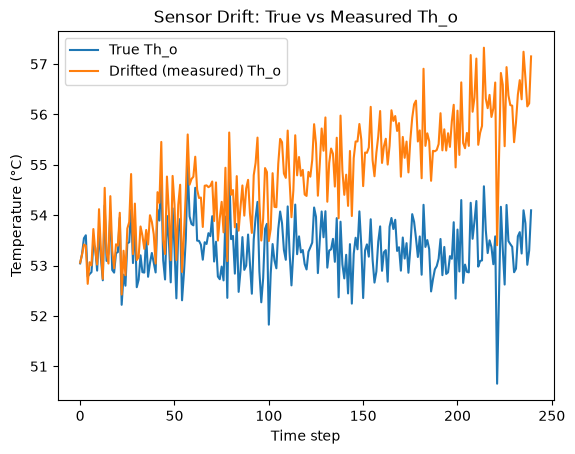

In [7]:
#Using same pipeline from 02_data_generation
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
sys.path.append('../src')
from heatexchanger_model import effectiveness_ntu

timestamps = pd.date_range(start="2026-01-01 00:00", periods=240, freq="1min")

Th_i_values = np.random.normal(loc=80, scale=0.5, size=240)
Tc_i_values = np.random.normal(loc=20, scale=0.5, size=240)
mdot_h_values = np.random.normal(loc=1.5, scale=0.03, size=240)
mdot_c_values = np.random.normal(loc=1.0, scale=0.02, size=240)

cp = 4180
A = 12

#FOULING - U decreases over time
U_fouled = np.linspace(850,700,240) #Linspace generates evenly spaced numbers from the start to the stop value with certain increment value creates an array

results_list = []
for i in range(240):
    results = effectiveness_ntu(Th_i_values[i], Tc_i_values[i], mdot_h_values[i], mdot_c_values[i], cp, U_fouled[i], A)
    results_list.append(results)

# What should be happening is because U is dropping, NTU also drops which lowers effectiveness, and because Q = effectiveness x Qmax if the
# effectiveness drops Q also drops which means Th_o gets higher as Th_o = Th_i - Q/C_h, which means less heat is removed meaning less temperature drop
# So Th_o goes up with fouling meaning the hot water cools down less by the time it exits the heat exchanger (exhanger is worse at transferring heat)
# so it exits hotter

#SENSOR DRIFT - Th_o measurement drifts
#Load the CSV for our baseline data back in 
baseline_df = pd.read_csv("../data/baseline_data.csv")
Th_o_true = baseline_df["Th_o_true"].values
Tc_o_true = baseline_df["Tc_o_true"].values
sensor_noise_Th = np.random.normal(loc=0, scale=0.2, size=240)

#Creating the drift by 3 degrees
sensor_drift = np.linspace(0,3,240)
Th_o_drift = Th_o_true + sensor_noise_Th + sensor_drift

#Plotting the Th_true vs the Th_drift to visualise the drift and confirm it is happening
plt.plot(Th_o_true, label="True Th_o")
plt.plot(Th_o_drift, label="Drifted (measured) Th_o")
plt.xlabel("Time step")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.title("Sensor Drift: True vs Measured Th_o")
plt.show()